#Comparison of Optimization Algorithms (CG, Nelder-Mead, Bounded)

In [6]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
import pandas as pd

## 0. Program for the gradient descent algorithm.

In [7]:
def optimizeGD(x0, f, df, a0 = 0.005):
    res = Result()
    for iteration in range(20):
      st = []
      for t in x0:
        st.append(t)
      res.steps.append(st)
      x_start = x0.copy()
      x_end = df(x0)
      for k in range(len(x_end)):
        x_end[k] *= a0
      for t in range(len(x0)):
        x_end[t] = x0[t] - x_end[t]
      x0 = x_end
    res.x_result = x0
    res.f_result = f(x0)
    return res

class Result:
  def __init__(self):
    self.x_result = []
    self.f_result = None
    self.steps = []

  def __str__(self):
    return f"Minimum: x = {self.x_result}, f(x) = {self.f_result}"

  def iterations(self):
    self.data = []
    for t in self.steps:
      self.data.append(t.append(f(t)))
    col = []
    for t in range(len(self.x_result)):
      col.append(f"x{t}")
    col.append("f(x)")
    self.data = pd.DataFrame(self.steps, columns=col)
    display(self.data)

  def plot(self, xg, yg):
    plt.figure()
    plt.plot(self.steps[0][0], self.steps[0][1], marker="o", markersize=5, markeredgecolor = "red", markerfacecolor="red")
    for t in range(len(self.steps) - 1):
      plt.arrow(self.steps[t][0], self.steps[t][1], self.steps[t + 1][0]-self.steps[t][0], self.steps[t + 1][1]-self.steps[t][1], width = 0.00000000000000005, ec='w')
      plt.plot(self.steps[t][0], self.steps[t][1], marker="o", markersize=2, markeredgecolor = "red", markerfacecolor="red")
    plt.plot(self.steps[len(self.steps) - 1][0], self.steps[len(self.steps) - 1][1], marker="o", markersize=2, markeredgecolor = "red", markerfacecolor="red")

    minX = min(x[0] for x in self.steps)
    maxX = max(x[0] for x in self.steps)
    minY = min(x[1] for x in self.steps)
    maxY = max(x[1] for x in self.steps)

    if minX < 0: minX *= 1.1
    elif minX > 0: minX *= 0.9
    else: minX = -0.1

    if maxX < 0: maxX *= 0.9
    elif maxX > 0: maxX *= 1.1
    else: maxX = 0.1

    if minY < 0: minY *= 1.1
    elif minY > 0: minY *= 0.9
    else: minY = -0.1

    if maxY < 0: maxY *= 0.9
    elif maxY > 0: maxY *= 1.1
    else: maxY = 0.1

    plt.imshow(f([xg, yg]), extent=[minX, maxX, minY, maxY], origin = 'lower')
    plt.colorbar()
    plt.show()


## 1. Rosenbrock function

In [8]:
def f(x):
    return 100*((x[1] - (x[0]**2))**2) + (1 - x[0])**2

def df(x):
    return [400*(x[0]**3) + x[0]*(2 - 400*x[1]) - 2, 200*x[1] - 200*(x[0]**2)]

x = np.linspace(-5, 5)
y = np.linspace(-5, 5)
xg, yg = np.meshgrid(x, y)

### a) Initial point is (-1,1)

#### α is 1/400:

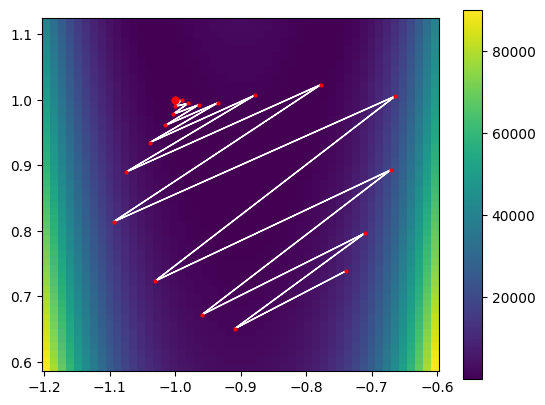

Minimum: x = [-0.8725465525879312, 0.6428281567080404], f(x) = 4.910876714796842


In [9]:
res = optimizeGD([-1, 1], f, df, 1/400)
res.plot(xg, yg)
print(res)
#print('-'*90)
#res.iterations()

#### α is 1/2:

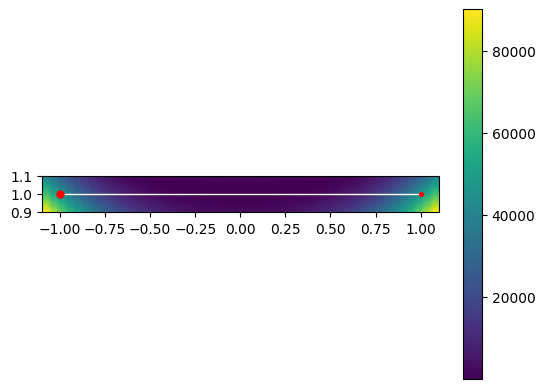

Minimum: x = [1.0, 1.0], f(x) = 0.0


In [10]:
res = optimizeGD([-1, 1], f, df, 1/2)
res.plot(xg, yg)
print(res)
#print('-'*90)
#res.iterations()

#### Using python minimization algorithm:

In [11]:
optimize.minimize(f, x0=[-1, 1], method='CG')

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 2.0064831557893402e-11
       x: [ 1.000e+00  1.000e+00]
     nit: 31
     jac: [ 7.065e-07 -3.539e-07]
    nfev: 186
    njev: 62

#### Conclusion:

Custom algorithm with α = 1/400 did not find the minimum.

Custom algorithm with α = 1/2 found the global minimum in the first iteration by accident.

Python algorithm found global minimum significantly better than the first attempt, but worse than the second.

### b) Pathes from different points

#### Initial point is (0, 0):

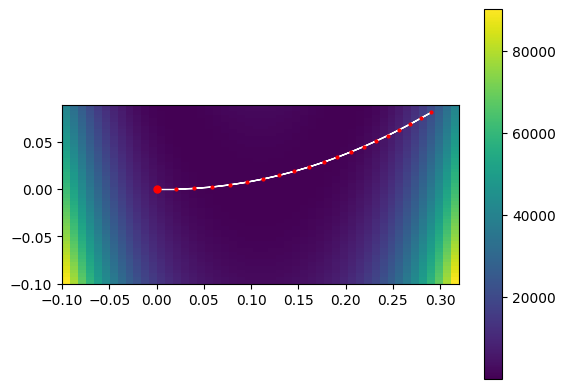

Minimum: x = [0.30119666662513, 0.08779266409250717], f(x) = 0.4891826957661203


In [12]:
res = optimizeGD([0, 0], f, df, 1/100)
res.plot(xg, yg)
print(res)
#print('-'*90)
#res.iterations()

In [13]:
optimize.minimize(f, x0=[0, 0], method='CG')

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 2.0085382242752512e-11
       x: [ 1.000e+00  1.000e+00]
     nit: 21
     jac: [ 5.412e-06 -2.705e-06]
    nfev: 165
    njev: 55

#### Initial point is (-1, -1)

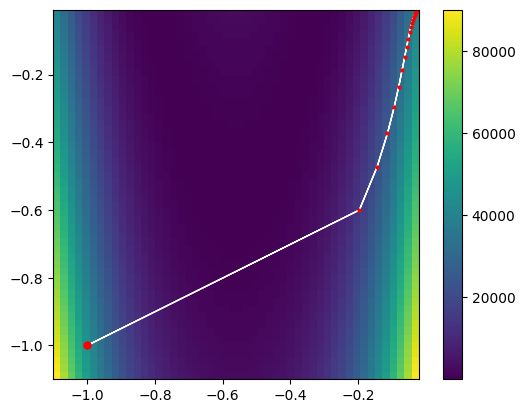

Minimum: x = [-0.021481566136634444, -0.007156360447569603], f(x) = 1.0492277052650352


In [14]:
res = optimizeGD([-1, -1], f, df, 1/1000)
res.plot(xg, yg)
print(res)
#print('-'*90)
#res.iterations()

In [15]:
optimize.minimize(f, x0=[-1, -1], method='CG')

 message: Desired error not necessarily achieved due to precision loss.
 success: False
  status: 2
     fun: 7.45592153442599e-12
       x: [ 1.000e+00  1.000e+00]
     nit: 21
     jac: [ 4.241e-05 -1.925e-05]
    nfev: 210
    njev: 66

#### Initial point is (1, 1)

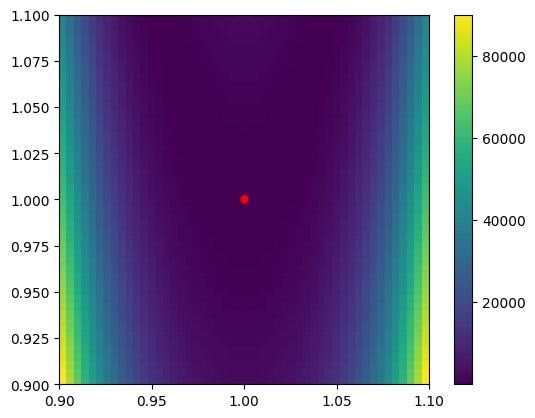

Minimum: x = [1.0, 1.0], f(x) = 0.0


In [16]:
res = optimizeGD([1, 1], f, df, 1/1000)
res.plot(xg, yg)
print(res)
#print('-'*90)
#res.iterations()

In [17]:
optimize.minimize(f, x0=[1, 1], method='CG')

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 0.0
       x: [ 1.000e+00  1.000e+00]
     nit: 0
     jac: [ 5.975e-06  1.490e-06]
    nfev: 3
    njev: 1

#### Conclusion:

Python algorithm works better than the custom one in first two cases. In the third case initial point is the global minimum, so both algorithms are done well.

## 2. Custom function

In [18]:
def fc(x):
    return 10*(x[0]**2) + 2*(4*x[1] + x[2])**2 + (x[3] + 1)**2 + x[2]**2

def dfc(x):
    return [20*x[0], 64*x[1] + 16*x[2], 6*x[2] + 16*x[1], 2*x[3] + 2]

x = np.linspace(-5, 5)
y = np.linspace(-5, 5)
xg, yg = np.meshgrid(x, y)

res = optimizeGD([1, 1, 1, 1], fc, dfc, 1/300)
print(res)
#print('-'*90)
#res.iterations()

Minimum: x = [0.2516144232366704, -0.15132108902778646, 0.615791670704035, 0.7495654057874349], f(x) = 4.073497477963749


In [19]:
optimize.minimize(fc, x0=[-1, 1, -1, 1], method='CG')

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 2.1264747844319121e-13
       x: [ 9.351e-08  7.838e-08 -3.487e-07 -1.000e+00]
     nit: 30
     jac: [ 2.019e-06 -8.641e-08 -7.936e-07 -5.162e-08]
    nfev: 275
    njev: 55

Python algorithm works significantly better than the custom one.

## 3. Conclusion

To minimize function by custom algorithm, 20 iterations are not enough (in most cases), python's pre-implemented function works significantly better.

To improve productivity, number of iterations should be increased. To improve accuracy, α should be decreased.